In [13]:
from sklearn.datasets import make_classification
import numpy as np
X,y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0,
                          n_classes=2, n_clusters_per_class=1, random_state=41, hypercube=False, class_sep=10)

In [14]:
# Parameter                              Meaning
# 1. n_samples=100                       Create 100 data points.
# 2. n_features=2                        Each point has 2 features (2 columns).
# 3. n_informative=1                     Only 1 feature actually determines the class.
# 4. n_redundant=0                       No redundant (derived) features are created.
# 5. n_classes=2                         There are 2 classes: 0 and 1.
# 6. n_clusters_per_class=1              Each class forms one cluster.
# 7. random_state=41                     Makes the dataset reproducible.
# 8. hypercube=False                     Changes how clusters are generated.
# 9. class_sep=10                        Makes the two classes very far apart.

In [15]:
import matplotlib.pyplot as plt

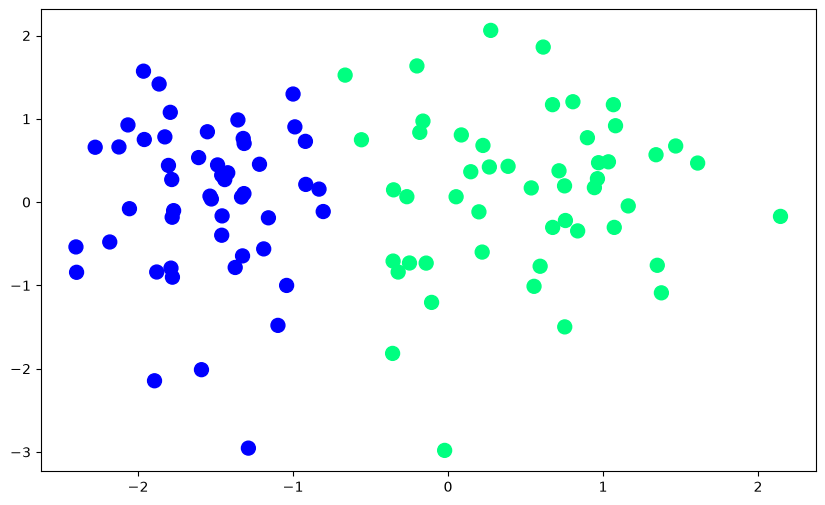

In [16]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1], c=y, cmap='winter',s=100)

In [20]:
def perceptron(X,y):
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr * (y[j] -y_hat) *X[j]

    return weights[0],weights[1:]

In [21]:
def step(z):
         return 1 if z>0 else 0

In [22]:
intercept_,coef_ = perceptron(X,y)
print(coef_)
print(intercept_)

[1.28601271 0.09059292]
1.0


In [24]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

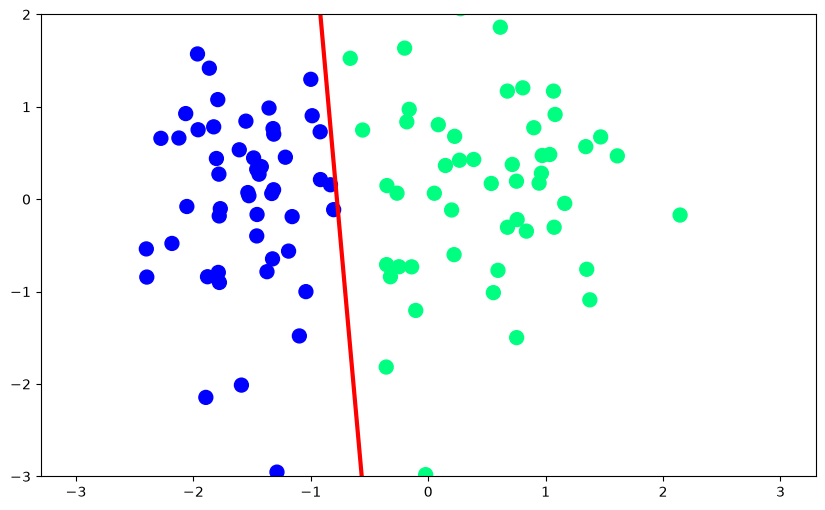

In [25]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [26]:
def perceptron(X,y):
    
    m = []
    b = []
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))
        
    return m,b

In [27]:
m,b = perceptron(X,y)

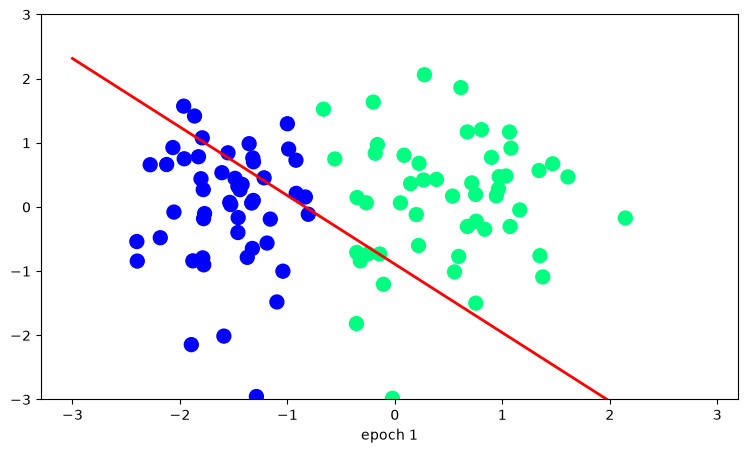

In [31]:

%matplotlib inline
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] +b[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m[0] +b[0] , 'r-', linewidth=2)
plt.ylim(-3,3)
def update(i):
,    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    # return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)

<p>The slope is =></p>
<pre>
m = − w1
     ------ 
       w2
</pre>

<p>The intercept is =></p>
<pre>
b = − w0
     ------
      w2
</pre>


In [32]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)

LogisticRegression()

m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

(-3.0, 2.0)

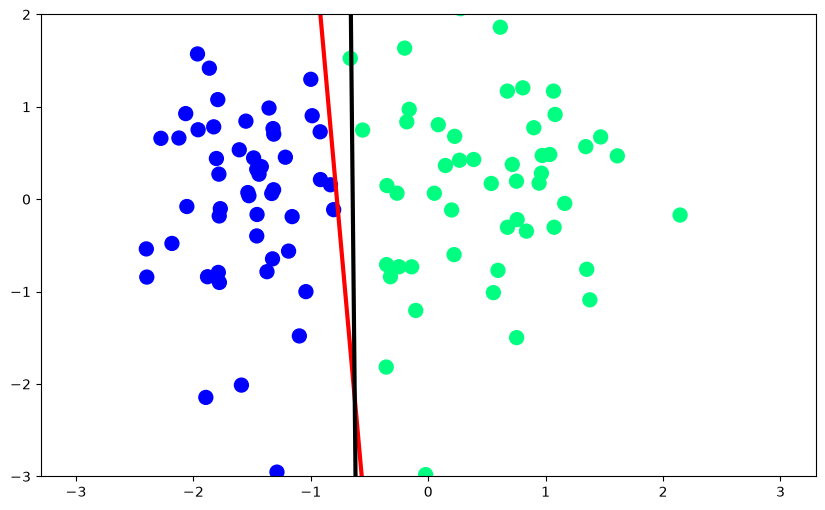

In [33]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)